# Cluster on a substrate
  
  Having defined a cluster and a substrate separately, we now put them together.
  In this rigid model the interaction is simple: evaluate the substrate energy
  at each particle position, then sum to get the total energy, force on the CM,
  and torque around the CM:
  
  $$E = \sum_{i=1}^N V(\mathbf{r}_i), \qquad
    \mathbf{F} = -\sum_i \nabla V(\mathbf{r}_i), \qquad
    \tau = -\sum_i (\mathbf{r}_i - \mathbf{r}_\text{cm}) \times \nabla V(\mathbf{r}_i)$$
    
  This notebook covers:
  1. System definition (substrate + cluster parameters)
  2. Snapshot inspection at fixed $(\theta, \mathbf{r}_\text{cm})$
  3. Translational energy landscape $E(x_\text{cm}, y_\text{cm})$ at fixed $\theta$
  4. Rotational landscape $E(\theta)$ at fixed CM
  5. Roto-translational landscape: global minimum search

In [1]:
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from flake.substrate import (calc_matrices_bvect, substrate_from_params,
                              get_ks)
from flake.cluster  import rotate, cluster_from_params
from flake.maps     import translational_map, rotational_map, rototrasl_map
from flake.plot     import (get_brillouin_zone_2d, plot_BZ2d,
                             plot_lattice_vectors, plt_cosmetic)

### System definition
  
  We define a sinusoidal triangular substrate and a circular cluster on top.
  The mismatch ratio $\rho$ controls the ratio of cluster to substrate lattice
  spacing. $\rho = 1$ gives a fully commensurate contact (maximum friction);
  $\rho \neq 1$ introduces a lattice mismatch — the first step toward superlubricity.

In [2]:
rho = 1.0 + 1/20  # rho=1: commensurate contact. Try rho=1+1/20 for mismatch.

ks = get_ks(1, 3, 4./3., 0.)   # triangular substrate wave vectors

params = {
    # --- substrate (sinusoidal, triangular symmetry) ---
    'sub_basis':  [[0, 0]],
    'epsilon':    1,
    'well_shape': 'sin',
    'ks':         ks,
    # --- cluster (triangular lattice, scaled by rho) ---
    'a1':            list(rho * np.array([1.,   0.])),
    'a2':            list(rho * np.array([0.5, -sqrt(3.)/2.])),
    'cl_basis':      [[0., 0.]],
    'cluster_shape': 'circle',
    'N1': 20, 'N2': 20,
}

In [3]:
# Substrate lattice matrix (needed for BZ overlay and fractional-coord grids).
# For the sinusoidal substrate we use the underlying triangular lattice b1, b2.
u, u_inv = calc_matrices_bvect([1, 0], [1./2., sqrt(3.)/2.])
S = u_inv.T   # rows are b1, b2

bz_kw = {'ls': '--', 'color': 'gray', 'lw': 1, 'fill': False}

pen_func, en_func, en_inputs = substrate_from_params(params)

#### Substrate potential
  
  Quick sanity check: plot the per-particle substrate energy on a 2D grid.

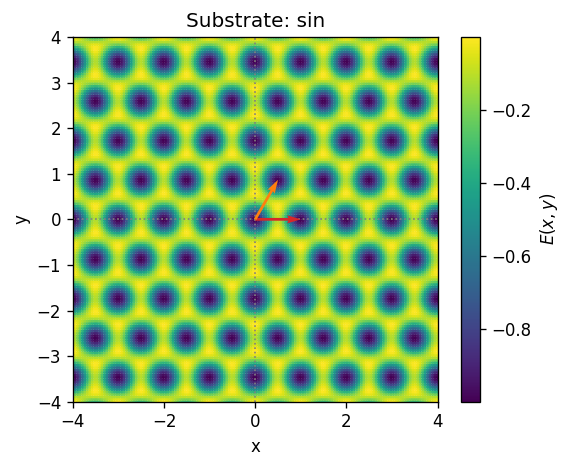

In [4]:
side = 4.
nx = ny = 150
xx, yy = np.meshgrid(np.linspace(-side, side, nx),
                     np.linspace(-side, side, ny))
p = np.stack([xx.ravel(), yy.ravel()], axis=1)
en_sub, _, _ = pen_func(p, np.array([0., 0.]), *en_inputs)

fig, ax = plt.subplots(dpi=120, figsize=(5, 4))
sc = ax.scatter(p[:,0], p[:,1], c=en_sub, s=1, rasterized=True)
plt.colorbar(sc, label=r'$E(x,y)$', ax=ax)
if params['well_shape'] != 'sin':
    plot_BZ2d(ax, get_brillouin_zone_2d(S), bz_kw)
plot_lattice_vectors(ax, S)
ax.set_xlim([-side, side])
ax.set_ylim([-side, side])
ax.set_xlabel('x  [a.u.]')
ax.set_ylabel('y  [a.u.]')
ax.set_title('Substrate: %s' % params['well_shape'])
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

### Cluster
  
  `cluster_from_params` returns positions in the **reference frame**:
  CM at the origin, $\theta = 0$.
  Rotation and translation are applied explicitly for display or static calculations.



Cluster circle, N=397, rho=1.050


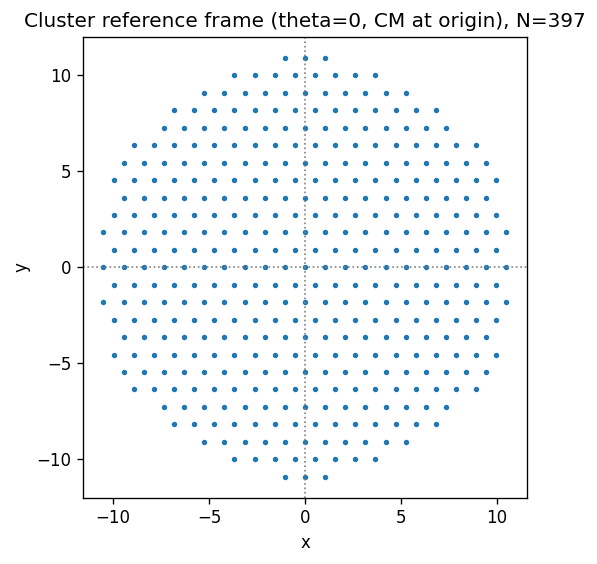

In [5]:
# cluster_from_params returns pos in the REFERENCE FRAME: CM at origin, theta=0.
# Rotation and translation are applied explicitly for display or static calculations.
pos = cluster_from_params(params)
N = pos.shape[0]
print('Cluster %s, N=%i, rho=%.3f' % (params['cluster_shape'], N, rho))

fig, ax = plt.subplots(dpi=120)
ax.scatter(pos[:,0], pos[:,1], s=5)
ax.set_title('Cluster reference frame (theta=0, CM at origin), N=%d' % N)
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

### Snapshots at fixed $(\theta, \mathbf{r}_\text{cm})$
  
  Place the cluster at several $(\theta, \mathbf{r}_\text{cm})$ configurations
  and inspect the per-particle energy $E_i$, force components $F_{x,i}$, $F_{y,i}$,
  and torque contribution $\tau_i$.
  
  Physical expectation for commensurate contact ($\rho = 1$):
  - At $\theta = 0$, $\mathbf{r}_\text{cm} = \mathbf{0}$: all particles in wells,
    $E \approx -\epsilon$ per particle, force and torque $\approx 0$ (energy minimum).
  - Off-minimum: particles straddle well edges, forces point back toward the minimum.
  


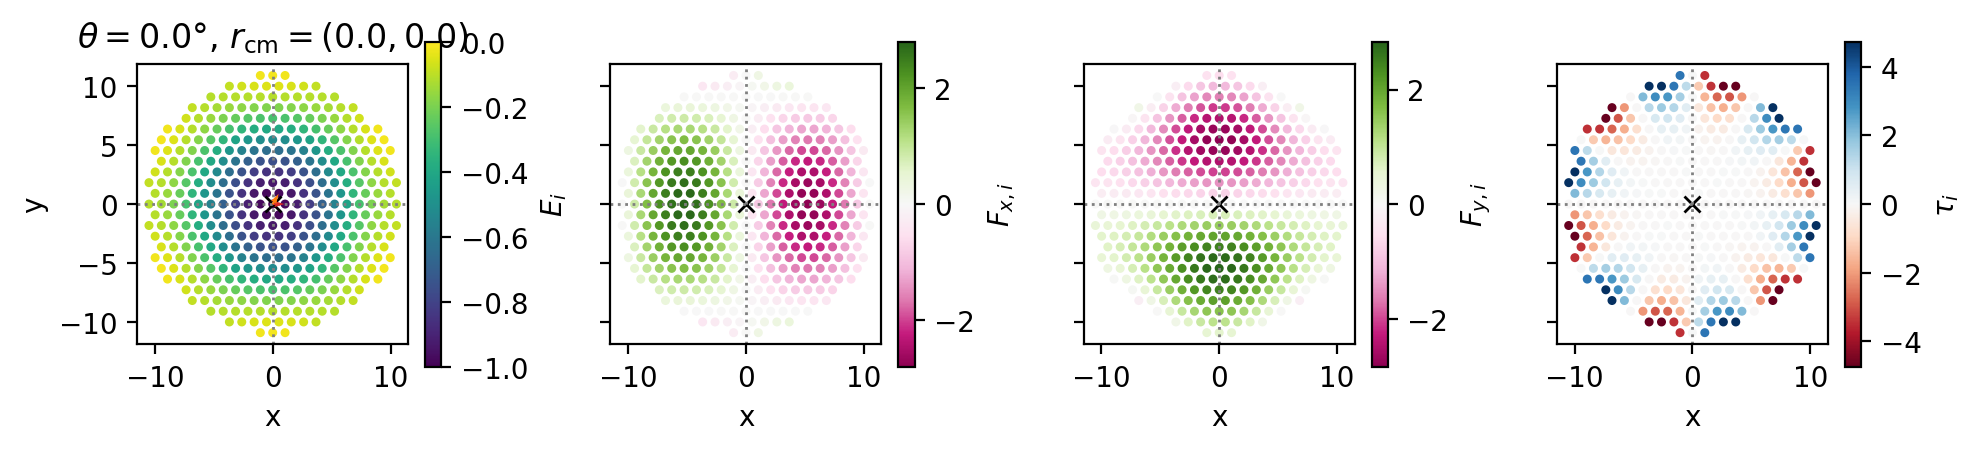

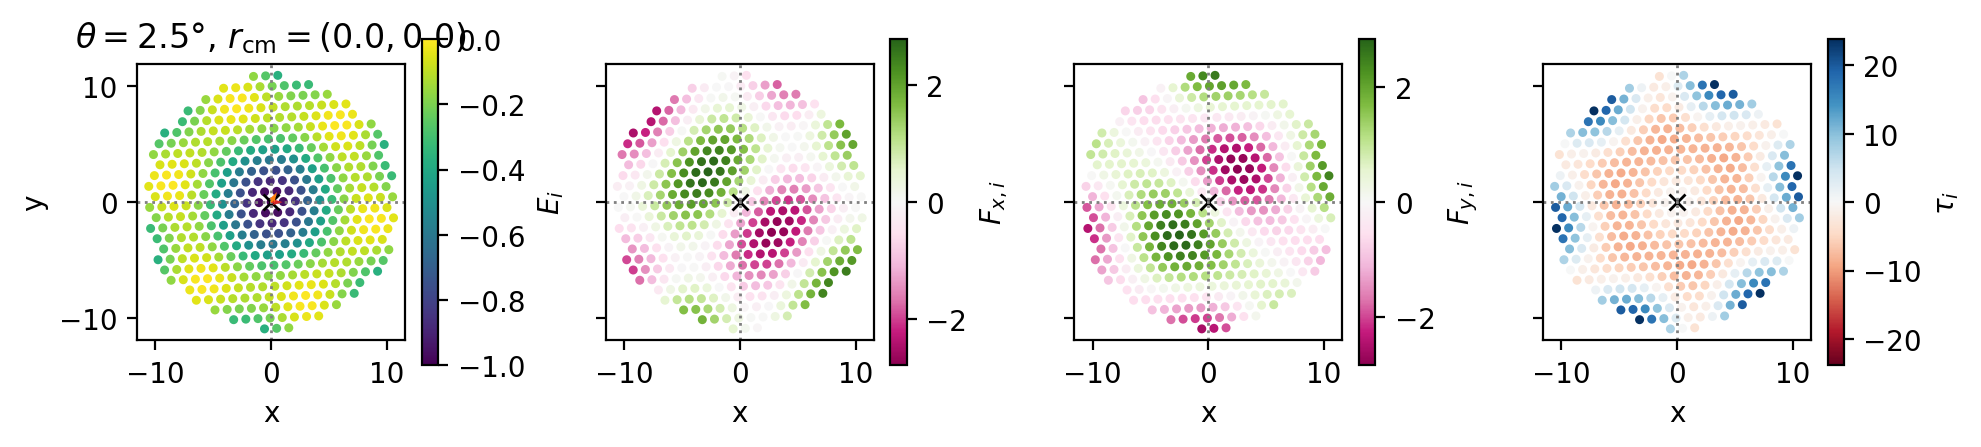

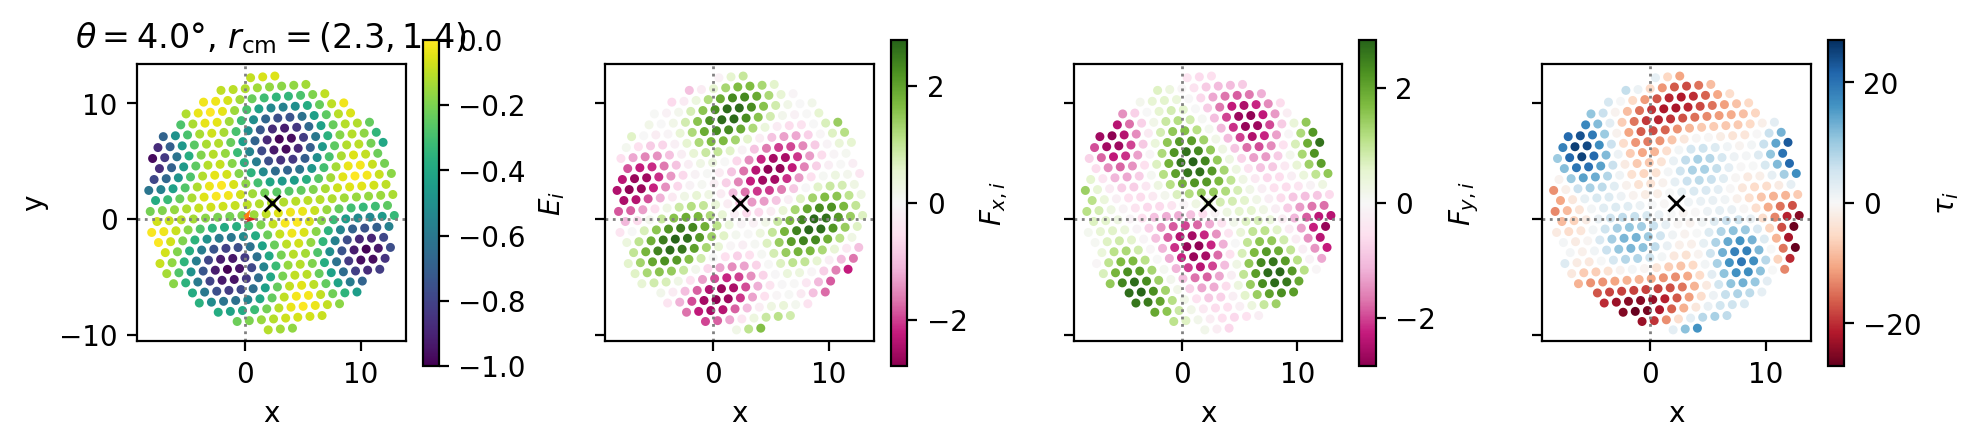

In [6]:
for theta, cm in [(0.,   [0.,  0. ]),    # commensurate minimum
                  (2.5,  [0.,  0. ]),    # slightly rotated
                  (4.,   [2.3, 1.4])]:   # rotated + shifted

    cm      = np.array(cm)
    pos_rot = rotate(pos, theta)
    en, F, tau = pen_func(pos_rot + cm, cm, *en_inputs)

    fig, axes = plt.subplots(1, 4, dpi=200, sharey=True, figsize=(10, 2.5))
    axE, axFx, axFy, axTau = axes
    s0 = 5
    xy = pos_rot + cm
    x0, x1 = xy[:,0].min() - 1., xy[:,0].max() + 1.
    y0, y1 = xy[:,1].min() - 1., xy[:,1].max() + 1.

    for ax, vals, label, cmap, vmax in [
        (axE,   en,     r'$E_i$',   'viridis', None),
        (axFx,  F[:,0], r'$F_{x,i}$', 'PiYG', np.abs(F[:,0]).max()),
        (axFy,  F[:,1], r'$F_{y,i}$', 'PiYG', np.abs(F[:,1]).max()),
        (axTau, tau,    r'$\tau_i$', 'RdBu',  np.abs(tau).max()),
    ]:
        norm = Normalize(-1., 0.) if ax is axE else Normalize(-vmax, vmax)
        sc   = ax.scatter(xy[:,0], xy[:,1], c=vals, s=s0,
                          cmap=cmap, norm=norm, rasterized=True)
        plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
        ax.plot(*cm, 'x', color='black', ms=6)
        if params['well_shape'] != 'sin':
            plot_BZ2d(ax, get_brillouin_zone_2d(S), bz_kw)
        ax.set_xlim([x0, x1])
        ax.set_ylim([y0, y1])
        plt_cosmetic(ax)

    plot_lattice_vectors(axE, S)
    axE.set_title(r'$\theta=%.1f°$, $r_\mathrm{cm}=(%.1f,%.1f)$' % (theta, *cm))
    for ax in axes[1:]:
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

### Translational energy landscape
  
  Scan the cluster CM over a 2D grid at fixed orientation $\theta = 0$ and compute
  energy, force, and torque at each point.
  
  For the sinusoidal substrate there is no unit cell, so we use a Cartesian grid
  (`pos_cm_grid`). For Gaussian/tanh substrates, use fractional coordinates via
  `frac_x` / `frac_y` and `u_inv`.
  
  For a commensurate cluster the landscape has the full symmetry of the substrate
  and a barrier proportional to $N$ (static friction scales linearly with size).
  For a mismatched cluster ($\rho \neq 1$) the barrier is strongly suppressed.
  


In [7]:
# Sinusoidal substrate: Cartesian grid is required (no unit cell).
xx_cm = np.linspace(-1.5, 1.5, 100)
yy_cm = np.linspace(-1.5, 1.5, 100)
pos_cm_grid = np.array([[x, y] for x in xx_cm for y in yy_cm])

trasl = translational_map(
    pos, en_func, en_inputs, u_inv=None,
    n_x=150, n_y=150,
    pos_cm_grid=pos_cm_grid,
    n_jobs=1,
)

pp     = trasl['pos_cm']
enmap  = trasl['energy']
Fmap   = trasl['force']
taumap = trasl['torque']

print('E range: [%.4g, %.4g]  barrier: %.4g' % (
    enmap.min(), enmap.max(), enmap.max() - enmap.min()))

E range: [-133.9, -131.5]  barrier: 2.401


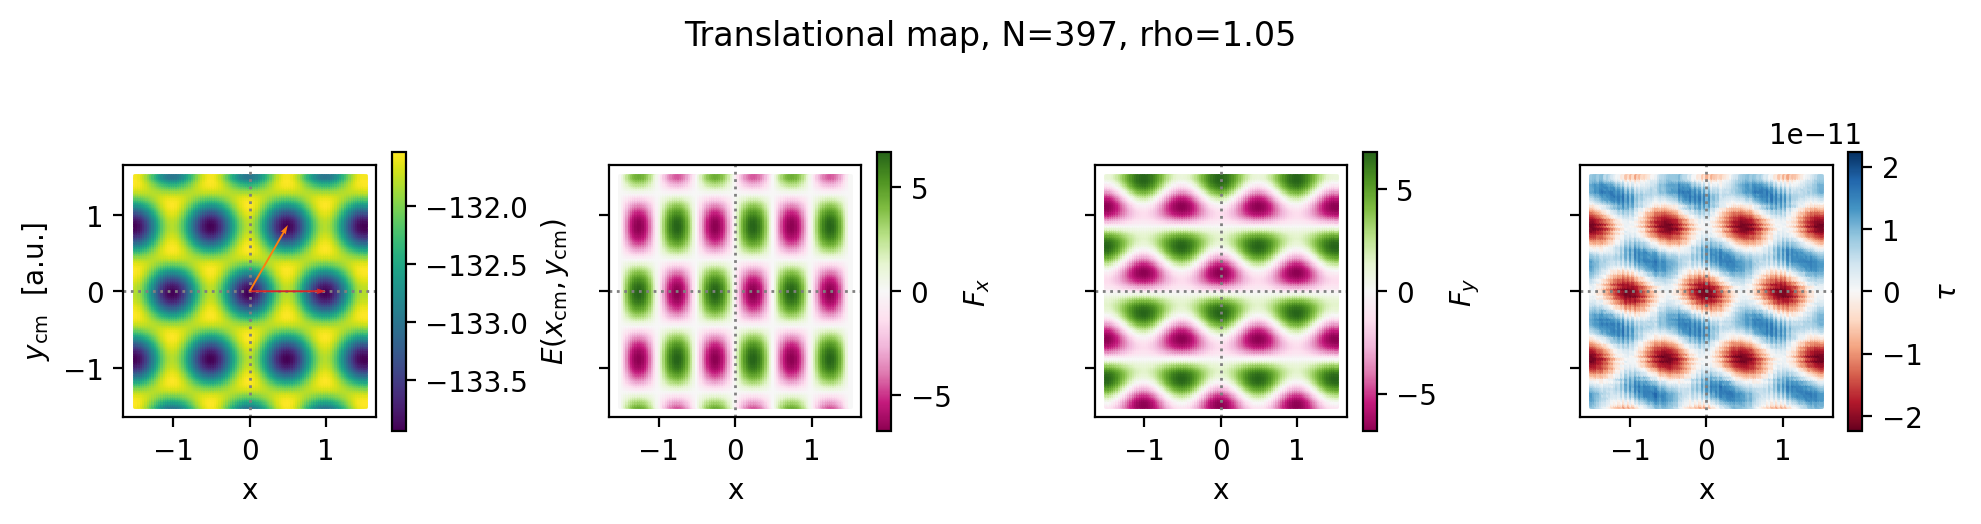

In [8]:
fig, axes = plt.subplots(1, 4, dpi=200, sharey=True, figsize=(10, 2.5))
axE, axFx, axFy, axTau = axes
s0 = 0.8

for ax, vals, label, cmap, symmetric in [
    (axE,   enmap,     r'$E(x_\mathrm{cm}, y_\mathrm{cm})$', 'viridis', False),
    (axFx,  Fmap[:,0], r'$F_x$',  'PiYG',  True),
    (axFy,  Fmap[:,1], r'$F_y$',  'PiYG',  True),
    (axTau, taumap,    r'$\tau$', 'RdBu',  True),
]:
    vmax = np.abs(vals).max()
    norm = Normalize(-vmax, vmax) if symmetric else None
    sc   = ax.scatter(pp[:,0], pp[:,1], c=vals, s=s0,
                      cmap=cmap, norm=norm, marker='s', rasterized=True)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
    if params['well_shape'] != 'sin':
        plot_BZ2d(ax, get_brillouin_zone_2d(S), bz_kw)
    ax.set_xlabel(r'$x_\mathrm{cm}$  [a.u.]')
    plt_cosmetic(ax)

plot_lattice_vectors(axE, S)
axE.set_ylabel(r'$y_\mathrm{cm}$  [a.u.]')
for ax in axes[1:]:
    ax.set_ylabel('')
plt.suptitle('Translational map, N=%d, rho=%.2f' % (N, rho), y=1.01)
plt.tight_layout()
plt.show()

### Rotational energy landscape
  
  Scan the cluster orientation $\theta$ at fixed CM position.
  The energy is periodic with the symmetry of the contact:
  for a triangular cluster on a triangular substrate the period is $60°$.
  The torque $\tau = -dE/d\theta$ changes sign at every energy extremum
  (zero torque $\Rightarrow$ mechanical equilibrium).



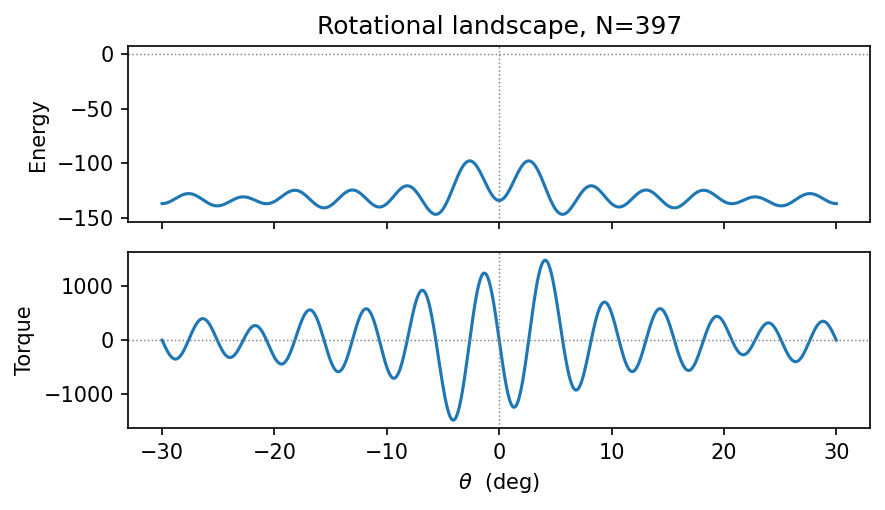

In [9]:
theta_deg = np.linspace(-30., 30., 1000)
roto = rotational_map(
    pos, en_func, en_inputs,
    theta_deg=theta_deg,
    pos_cm=np.array([0., 0.]),
    n_jobs=1,
)

fig, (axE, axTau) = plt.subplots(2, 1, dpi=150, sharex=True, figsize=(6, 3.5))
axE.plot(roto['theta'], roto['energy'])
axTau.plot(roto['theta'], roto['torque'])
for ax, label in [(axE, 'Energy'), (axTau, 'Torque')]:
    ax.axhline(0., ls=':', color='gray', lw=0.7)
    ax.axvline(0., ls=':', color='gray', lw=0.7)
    ax.set_ylabel(label)
axTau.set_xlabel(r'$\theta$  (deg)')
axE.set_title('Rotational landscape, N=%d' % N)
plt.tight_layout()
plt.show()

### Roto-translational landscape
  
  For each orientation $\theta$, scan the translational grid and record the minimum
  energy. This gives the effective rotational potential after optimising over
  all CM positions — the true minimum-energy configuration as a function of $\theta$.
  
  Computational cost: $n_\theta \times n_x \times n_y$ energy evaluations.
  Use `n_jobs > 1` to parallelise over $\theta$ values.

In [10]:
theta_scan = np.linspace(-30., 30., 200)

rtmap = rototrasl_map(
    pos, en_func, en_inputs, u_inv,
    theta_deg=theta_scan,
    n_x=100, n_y=100,
    frac_x=(0., 1.), frac_y=(0., 1.),
    n_jobs=1,
)

# Global minimum across all (theta, x_cm, y_cm).
flat_idx  = np.argmin(rtmap['energy'])
ith, ixy  = np.unravel_index(flat_idx, rtmap['energy'].shape)
thmin     = rtmap['theta'][ith]
cmmin     = rtmap['pos_cm'][ith, ixy]
emin      = rtmap['energy'][ith, ixy]
fmin      = rtmap['force'][ith, ixy]
taumin    = rtmap['torque'][ith, ixy]

print('N=%i  E_min=%.4g  theta=%.4g deg  CM=(%.4g, %.4g)'
      % (N, emin, thmin, *cmmin))
print('Residual force=(%.2e, %.2e)  torque=%.2e  (should be ~0 at minimum)'
      % (*fmin, taumin))

N=397  E_min=-149.7  theta=2.563 deg  CM=(1, 0.5774)
Residual force=(6.23e-14, -3.91e-13)  torque=4.59e+01  (should be ~0 at minimum)


#### Minimum-energy configuration
  
  At the global minimum all particles should sit near the bottoms of substrate
  wells ($E_i \approx -\epsilon$), and the residual force $|\mathbf{F}|$
  and torque $|\tau|$ should be close to zero.



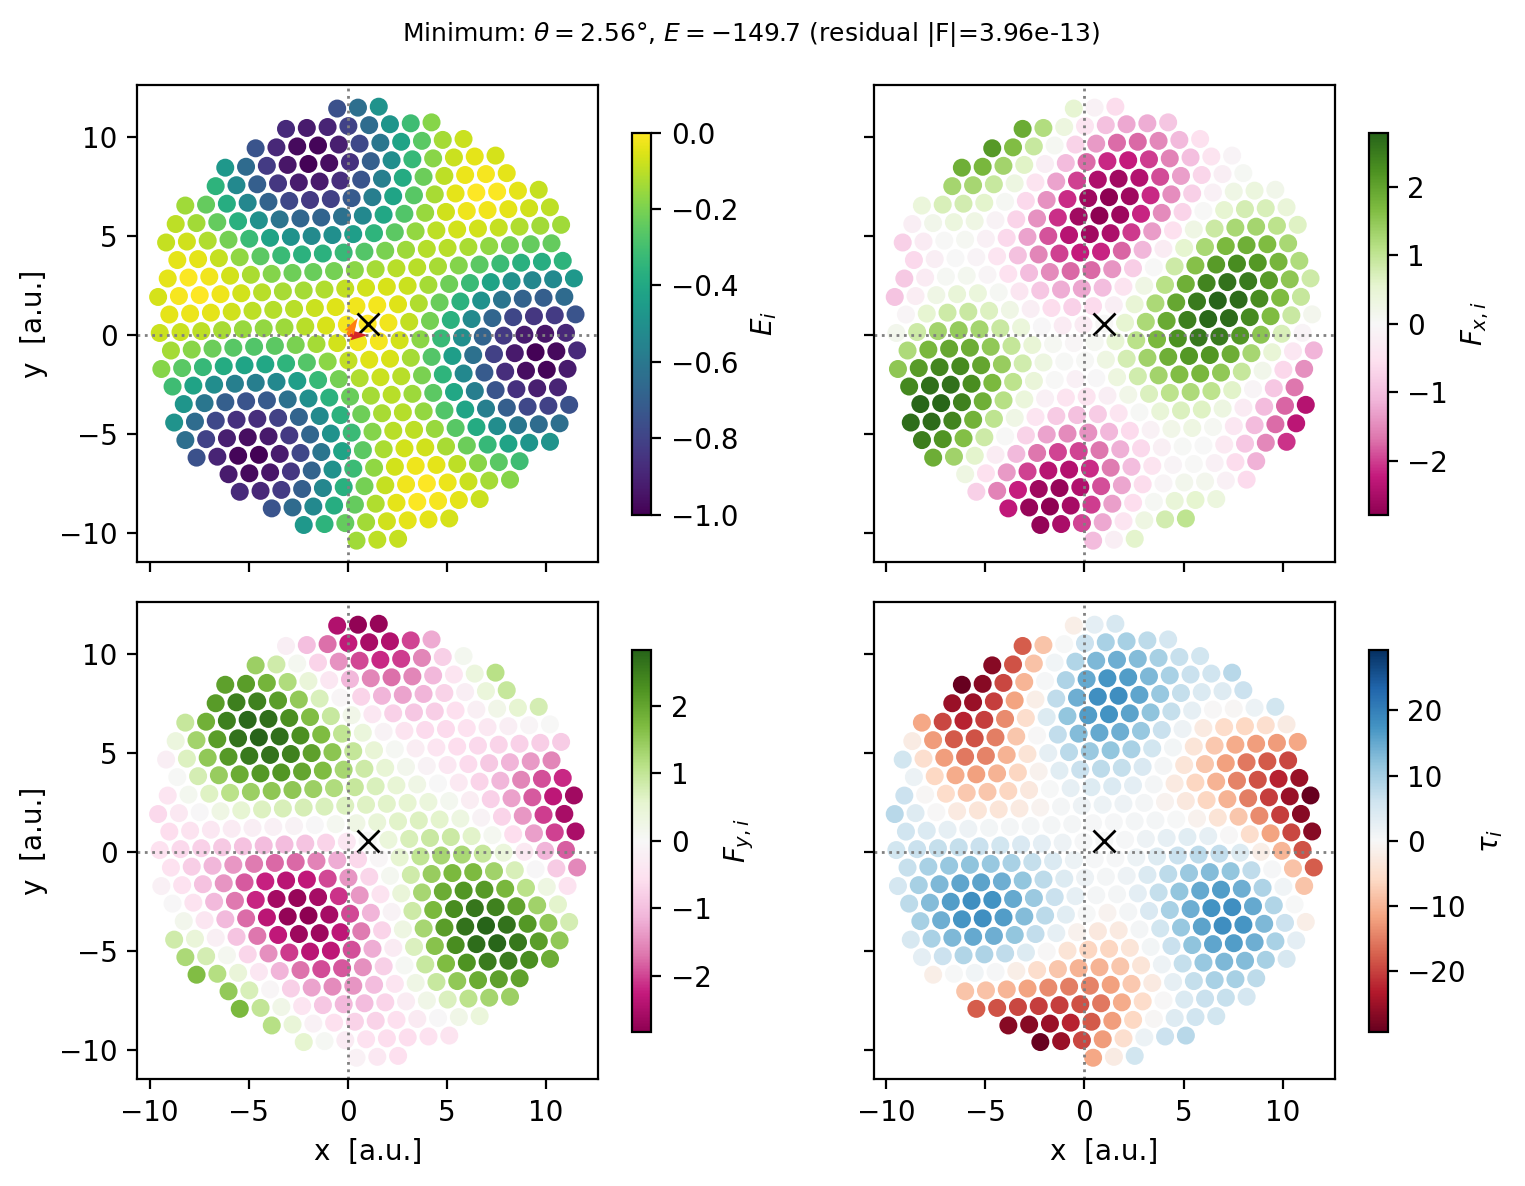

In [11]:
pos_min = rotate(pos, thmin) + cmmin
en_m, F_m, tau_m = pen_func(pos_min, cmmin, *en_inputs)

fig, axes = plt.subplots(2, 2, dpi=200, sharex=True, sharey=True, figsize=(8, 6))
(axE, axFx), (axFy, axTau) = axes
s0 = 30

for ax, vals, label, cmap, symmetric in [
    (axE,   en_m,     r'$E_i$',     'viridis', False),
    (axFx,  F_m[:,0], r'$F_{x,i}$', 'PiYG',   True),
    (axFy,  F_m[:,1], r'$F_{y,i}$', 'PiYG',   True),
    (axTau, tau_m,    r'$\tau_i$',  'RdBu',   True),
]:
    vmax = np.abs(vals).max()
    norm = Normalize(-1., 0.) if ax is axE else Normalize(-vmax, vmax)
    sc   = ax.scatter(pos_min[:,0], pos_min[:,1], c=vals, s=s0,
                      norm=norm, cmap=cmap, rasterized=True)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
    ax.plot(*cmmin, 'x', color='black', ms=8)
    if params['well_shape'] != 'sin':
        plot_BZ2d(ax, get_brillouin_zone_2d(S), bz_kw)
    plt_cosmetic(ax)

plot_lattice_vectors(axE, S)
for ax in [axFx, axTau]:
    ax.set_ylabel('')
for ax in [axE, axFx]:
    ax.set_xlabel('')
for ax in [axFy, axTau]:
    ax.set_xlabel('x  [a.u.]')
for ax in [axE, axFy]:
    ax.set_ylabel('y  [a.u.]')
fig.suptitle(r'Minimum: $\theta=%.2f°$, $E=%.4g$ (residual |F|=%.2e)'
             % (thmin, emin, np.linalg.norm(fmin)), fontsize=9)
plt.tight_layout()
plt.show()